# Praktikum Technische Informatik
---
# Versuch 7: Verlustbehaftete Audiocodierung
---

<h1>Inhaltsverzeichnis<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Verlustbehaftete-Audiocodierung" data-toc-modified-id="Verlustbehaftete-Audiocodierung-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Verlustbehaftete Audiocodierung</a></span></li><li><span><a href="#Darstellung-von-Audiosignalen" data-toc-modified-id="Darstellung-von-Audiosignalen-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Darstellung von Audiosignalen</a></span><ul class="toc-item"><li><span><a href="#Diskrete-Fourier-Transformation" data-toc-modified-id="Diskrete-Fourier-Transformation-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>Diskrete Fourier-Transformation</a></span></li><li><span><a href="#Inverse-Diskrete-Fourier-Transformation" data-toc-modified-id="Inverse-Diskrete-Fourier-Transformation-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>Inverse Diskrete Fourier-Transformation</a></span></li><li><span><a href="#Kurzzeit-Fourier-Transformation" data-toc-modified-id="Kurzzeit-Fourier-Transformation-2.3"><span class="toc-item-num">2.3&nbsp;&nbsp;</span>Kurzzeit-Fourier-Transformation</a></span></li></ul></li><li><span><a href="#Eigenschaften-des-menschlichen-Gehörs" data-toc-modified-id="Eigenschaften-des-menschlichen-Gehörs-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Eigenschaften des menschlichen Gehörs</a></span><ul class="toc-item"><li><span><a href="#Dezibel" data-toc-modified-id="Dezibel-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Dezibel</a></span></li><li><span><a href="#Die-Ruhehörschwelle" data-toc-modified-id="Die-Ruhehörschwelle-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>Die Ruhehörschwelle</a></span></li><li><span><a href="#Verdeckung" data-toc-modified-id="Verdeckung-3.3"><span class="toc-item-num">3.3&nbsp;&nbsp;</span>Verdeckung</a></span><ul class="toc-item"><li><span><a href="#Verdeckung-im-Frequenzbereich" data-toc-modified-id="Verdeckung-im-Frequenzbereich-3.3.1"><span class="toc-item-num">3.3.1&nbsp;&nbsp;</span>Verdeckung im Frequenzbereich</a></span></li><li><span><a href="#Verdeckung-im-Zeitbereich" data-toc-modified-id="Verdeckung-im-Zeitbereich-3.3.2"><span class="toc-item-num">3.3.2&nbsp;&nbsp;</span>Verdeckung im Zeitbereich</a></span></li></ul></li></ul></li><li><span><a href="#Das-MP3-Kompressionsverfahren" data-toc-modified-id="Das-MP3-Kompressionsverfahren-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Das MP3-Kompressionsverfahren</a></span><ul class="toc-item"><li><span><a href="#Hybride-Filterbänke-und-MDCT" data-toc-modified-id="Hybride-Filterbänke-und-MDCT-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>Hybride Filterbänke und MDCT</a></span></li><li><span><a href="#Quantisierung" data-toc-modified-id="Quantisierung-4.2"><span class="toc-item-num">4.2&nbsp;&nbsp;</span>Quantisierung</a></span></li><li><span><a href="#Das-psychoakustische-Modell" data-toc-modified-id="Das-psychoakustische-Modell-4.3"><span class="toc-item-num">4.3&nbsp;&nbsp;</span>Das psychoakustische Modell</a></span></li><li><span><a href="#Huffman-Codierung" data-toc-modified-id="Huffman-Codierung-4.4"><span class="toc-item-num">4.4&nbsp;&nbsp;</span>Huffman Codierung</a></span></li><li><span><a href="#MP3-Decodierer" data-toc-modified-id="MP3-Decodierer-4.5"><span class="toc-item-num">4.5&nbsp;&nbsp;</span>MP3 Decodierer</a></span></li></ul></li></ul></div>

## Verlustbehaftete Audiocodierung

Seit Jahren spalten sich die Musikliebhaber in zwei Lager: Die einen sehen in der verlustbehafteten Audiokompression einen Meilenstein der digitalen Audiosignalverarbeitung und -archivierung. Die anderen vertreten den Standpunkt, dass wahrer Musikgenuss nur bei unkomprimierten Signalquellen möglich sei.

Dieser Praktikumsversuch befasst sich mit den Ideen und Tricks der verlustbehafteten Audiokompression und stellt ihre praktische Umsetzung am Beispiel von MP3 vor.

**Wichtig: Lesen Sie zunächst dieses Skript und bearbeiten Sie danach die [Vorbereitungsaufgaben](Vorbereitungsaufgaben.ipynb)**

## Darstellung von Audiosignalen

Die einfachste digitale Darstellung von Audiosignalen ist die einer Sequenz $x[n] := x(nT)$ von Abtastwerten. Als Abtastfrequenz $f_s = 1/T$ wird in diesem Praktikumsversuch $44100 \text{ Hz}$ angenommen. Dies ist auch die Abtastfrequenz, die auf CDs verwendet wird. Der Wertebereich für jedes Sample beträgt $-1 \leq x[n] \leq +1$. Wird dieser Bereich überschritten, kommt es zu Verzerrungen (Clipping) bei der Signalausgabe.

Außer im Zeitbereich können Audiosignale auch im Frequenzbereich dargestellt und manipuliert werden. Hierzu dient die diskrete Fourier-Transformation.

### Diskrete Fourier-Transformation

Die diskrete Fourier-Transformation ist durch folgende Gleichung definiert:

\begin{equation}
        \displaystyle X[k]=\sum_{n=0}^{N-1} x[n]e^{-j2\pi \frac{nk}{N}} \qquad \text{ für } k=0,1,\dots,N-1
        \tag{7.1}\label{Gl.7.1}
\end{equation}

Die diskrete Fourier-Transformation berechnet aus einer endlichen Folge $x[n]$ mit $N$ Elementen die transformierte Folge $X[k]$, ebenfalls mit $N$ Elementen. Der Koeffizient $X[0]$ entspricht dabei dem Gleichanteil des Signals. Die Koeffizienten $X[i], i = 1,\dots,\frac{N}{2}$, geben die Amplitude und Phase der $i$-fachen Grundfrequenz an.




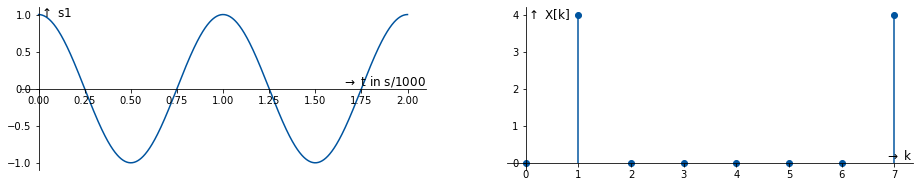

In [1]:
import sys
sys.path.insert(0,'ient_nb')

import matplotlib.pyplot as plt 
import matplotlib.pylab as pll
import numpy as np

import rwth_nb.plots.mpl_decorations as rwth_plt

from IPython.display import set_matplotlib_formats
set_matplotlib_formats('pdf', 'png')
plt.rcParams['savefig.dpi'] = 300

t = np.linspace(0,2/1000,801);
s1 = np.cos(2*np.pi*t*1000);

xn = s1[0:800:50];

xk =  np.fft.fft(xn,8);
xkr = xk.real



fig, ax = plt.subplots(1,2, figsize=(16, 3));

ax[0].xaxis.set_ticks_position('bottom')
ax[0].yaxis.set_ticks_position('left')

ax[1].xaxis.set_ticks_position('bottom')
ax[1].yaxis.set_ticks_position('left')

ax[0].plot( t*1000, s1);
markerline, stemlines, baseline = ax[1].stem(np.linspace(0,7,8),xk.real, use_line_collection=True)
plt.setp(baseline, 'color', 'none')

ax[0].set_xlabel(r'$\rightarrow$ t in s/1000');
ax[0].set_ylabel(r'$\uparrow$ s1');
rwth_plt.axis(ax[0]);

ax[1].set_xlabel(r'$\rightarrow$ k');
ax[1].set_ylabel(r'$\uparrow$ X[k]');
rwth_plt.axis(ax[1]);
plt.show()

>*Abbildung 7.1: Diskrete Fourier-Transformation*

Da der Wertebereich von Audiosignalen reell ist, bilden die Koeffizienten $X[1]$ und $X[N-1]$, $X[2]$ und $X[N-2]$ usw. konjugiert-komplexe Paare. Betrachtet man nur die Beträge der einzelnen Koeffizienten, so ist das Spektrum zur halben Abtastfrequenz symmetrisch. Welcher tatsächlichen Frequenz die einzelnen Koeffizienten in der Audiosignalverarbeitung entsprechen, hängt von der Abtastrate $f_s$ und der Transformationslänge $N$ ab. Die Grundfrequenz ist in Abhängigkeit dieser Größen in Gl. 7.2 definiert:

\begin{equation}
    \displaystyle f_\Delta = \frac{f_s}{N} \tag{7.2}\label{Gl.7.2}
\end{equation}

Wenn das Signal aus Abb. 7.1 mit einer Abtastrate von $f_s = 8000 \text{ Hz}$ abgetastet wird, entspricht der Koeffizient $X[1]$ bei einer Transformationslänge von $N = 8$ der Grundfrequenz $f_\Delta = 1000 \text{ Hz}$. 

Die Berechnung der diskreten Fourier-Transformation nach Gl. 7.1 erfordert $N^2$  komplexe Multiplikationen. Durch die Anwendung der schnellen Fourier-Transformation (*Fast Fourier Transform*, FFT) lässt sich der Rechenaufwand durch eine geschickte Wiederverwertung von Zwischenergebnissen auf $N log_2 N$ komplexe Multiplikationen verringern. Die Routinen *fft* und *ifft*, die in vielen numerischen Programmen zu finden sind, benutzen die schnelle Fourier-Transformation, um eine DFT zu berechnen.



### Inverse Diskrete Fourier-Transformation

Ein im Frequenzbereich vorliegendes Signal kann mit der inversen Diskreten Fourier-Transformation (Gl.7.3) in den Zeitbereich rücktransformiert werden.

\begin{equation}
    \displaystyle x[n]= \frac{1}{N}\sum_{k=0}^{N-1}X[k]e^{j2\pi\frac{nk}{N}} \qquad \text{für } n=0,1,\dots,N-1 \tag{7.3}\label{Gl.7.3}
\end{equation}


Auch für die Berechnung der inversen DFT kann die FFT benutzt werden. Die Gleichungen 7.1 und 7.3 bilden ein Transformationspaar.

### Kurzzeit-Fourier-Transformation

Die diskrete Fourier-Transformation ist nur für Folgen mit endlicher Länge durchführbar. Dabei wird angenommen, dass die betrachtete Folge ein Ausschnitt aus einer unendlich periodisch fortgesetzten Funktion sei.

In vielen Anwendungen, so auch in der Audiokodierung, ist der Verlauf eines Audiosignals sowohl im Zeit-, als auch im Frequenzbereich von Interesse. Damit man eine Repräsentation in beiden Bereichen erhält, wird das Audiosignal zunächst in kleine Blöcke unterteilt. Ein einfaches Ausschneiden eines Blockes aus einer längeren Folge ist äquivalent zu einer Multiplikation des Signals mit einer Rechteckfunktion. Eine Multiplikation im Zeitbereich entspricht im Frequenzbereich einer Faltungsoperation. Aus der Multiplikation im Zeitbereich mit einer Rechteckfunktion wird somit im Frequenzbereich eine Faltung mit der si-Funktion. Dadurch wird das
Spektrum verschmiert (*Leakage-Effekt*).

Durch die Wahl einer geeigneten Fensterfunktion kann dieser Effekt verringert werden. Bei
der MP3-Kodierung wird das Sinus-Fenster benutzt:

\begin{equation}
   \displaystyle w[n] = \sin \left[\frac{\pi(n+0,5)}{N}\right] \qquad \text{für } 0\leq n < N \tag{7.4}\label{Gl.7.4}
\end{equation}


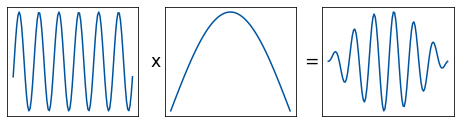

In [2]:
import sys
sys.path.insert(0,'ient_nb')

import matplotlib.pyplot as plt 
import matplotlib.pylab as pll

t1 = np.linspace(0,12*np.pi,100);
sig = np.sin(t1-0.1*np.pi);

t2 = np.linspace(0,99,100);
w = np.sin((np.pi*(t2+0.5))/100);


mul = np.multiply(sig,w);

fig,ax = plt.subplots(1,3, figsize=(8,2));

ax[0].tick_params(bottom=False, left=False, labelbottom=False, labelleft=False);
ax[1].tick_params(bottom=False, left=False, labelbottom=False, labelleft=False);
ax[1].set_ylabel("x",rotation=0, fontsize="xx-large", horizontalalignment = "right", verticalalignment="center");
ax[2].tick_params(bottom=False, left=False, labelbottom=False, labelleft=False);
ax[2].set_ylabel('=',rotation=0, fontsize="xx-large", horizontalalignment = "right", verticalalignment="center");

ax[0].plot(t1,sig);
ax[1].plot(t1,w);
ax[2].plot(t1,mul);

plt.show()

>*Abbildung 7.2: Multiplikation mit einer Fensterfunktion*


Abbildung 7.2 zeigt schematisch die Wirkungsweise einer Fensterfunktion. Das Signal auf der linken Seite - welches in der Praxis oft nicht ohne Sprungstellen periodisch fortsetzbar ist - wird mit der Fensterfunktion multipliziert. Das so gefensterte Signal wird an den Intervallgrenzen deutlich gedämpft wodurch der Leakage-Effekt stark verringert wird.

Offensichtlich gehen an den Intervallgrenzen durch die Fensterung Informationen verloren. Bei Anwendung der inversen Fourier-Transformation wird im Zeitbereich ebenfalls mit der Fensterfunktion multipliziert, so dass eine einfache Aneinanderreihung der rücktransformierten Blöcke zu starken Lautstärkeschwankungen führt. Diese Probleme kann man umgehen, indem man die Transformationsblöcke zu 50% überlappen läßt. Das gesamte Verfahren ist in der Literatur als *Kurzzeit-Fouriertransformation* (*Short-Time Fourier Transform*, STFT) bekannt.

Durch diese Überlappung verdoppelt sich allerdings die zu kodierende Datenmenge. Aus diesem Grund benutzt man in der Audiocodierung nicht die Kurzzeit-Fouriertransformation, sondern die *Modified Discrete Cosine Transform* (MDCT). Bei der MDCT reichen $N/2$ Koeffizienten zur Kodierung von $N$ Samples aus; allerdings tritt dadurch an den Blockrändern Aliasing auf. Nun ist die MDCT so strukturiert, dass das Aliasing von benachbarten (sich überlappenden) Blöcken sich jeweils aufhebt. Dadurch ist es möglich, den Vorteil des Überlapps (Vermeidung von Blockartefakten) zu bekommen, ohne die Datenmenge gegenüber einer nicht-überlappenden Transformation zu erhöhen.


## Eigenschaften des menschlichen Gehörs

Die verschiedenen Algorithmen der verlustbehafteten Audiokompression bauen letztlich alle auf der Kenntnis auf, dass das menschliche Gehör nicht alle Klänge wahrnehmen kann. Daher wird in diesem Abschnitt besprochen, welche Klänge das menschliche Ohr wahrnehmen kann und welche nicht. Vorher werden einige Grundlagen der Signalverarbeitung behandelt, die für das Verständnis des Versuchs notwendig sind.

### Dezibel

Das Dezibel stellt das Verhältnis zweier Werte an einer logarithmischen Skala dar. Es ist nicht für bestimmte physikalische Größen definiert, sondern liefert das logarithmierte Verhältnis zweier Größen. Vergleicht man Amplituden miteinander, so verwendet man Formel 7.5. Vergleicht man hingegen Leistungen, so benutzt man Formel 7.6. Der Grund hierfür liegt in der Tatsache, dass die Leistung eines Signals quadratisch mit seiner Amplitude zusammenhängt.

\begin{equation}
    \displaystyle [\text{dB}] = 20 \log_{10} \left(\frac{A}{A_0}\right) \tag{7.5}\label{Gl.7.5}
\end{equation}

\begin{equation}
    \displaystyle [\text{dB}] = 10 \log_{10} \left(\frac{P}{P_0}\right) \tag{7.6}\label{Gl.7.6}
\end{equation}


Um den Schalldruckpegel $L_p$ eines Signals in der logarithmischen Einheit Dezibel (dB) angeben zu können, wurde international eine Bezugsgröße $P_0 = 20\mu \text{Pa} = 10^{-12}W/m^2$ willkürlich festgelegt. Der Schalldruckpegel $L_p$ berechnet sich somit wie folgt:

\begin{equation}
    \displaystyle L_p = 20 \log_{10} \left(\frac{P}{10^{-12} \frac{W}{m^2}}\right) \tag{7.7}\label{Gl.7.7}
\end{equation}

### Die Ruhehörschwelle

Das menschliche Gehör hat ein begrenztes, frequenzabhängiges Auflösungsvermögen. Um einen Ton wahrzunehmen, muss der Ton über der so genannten *Ruhehörschwelle* liegen. Diese Ruhehörschwelle ist nicht nur von Mensch zu Mensch verschieden, sondern ändert (verschlechtert) sich auch im Leben eines Menschen gerade in den hohen Frequenzen. In Abb. 7.3 ist die Ruhehörschwelle $L$ einer normal hörenden Person in Abhängigkeit von der Frequenz $f$ skizziert. Sie
ist durch Mittelung über viele Versuchspersonen empirisch bestimmt worden.<cite data-cite="book:psychoacoustics"></cite><cite data-cite="book:ohr"></cite>


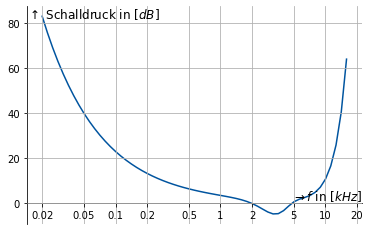

In [3]:
import sys
sys.path.insert(0,'ient_nb')

import matplotlib.pyplot as plt 
import matplotlib.pylab as pll

from IPython.display import set_matplotlib_formats
set_matplotlib_formats('pdf', 'png')
plt.rcParams['savefig.dpi'] = 300

data = pll.loadtxt('img/source/hoerschwelle.dat');

fig, ax = plt.subplots()
ax.plot( data[:,0], data[:,1]);
rwth_plt.axis(ax);

plt.xscale('log',basex=2);
plt.xticks([0.02,0.05,0.1,0.2,0.5,1,2,5,10,20],[0.02,0.05,0.1,0.2,0.5,1,2,5,10,20]);
plt.grid()
ax.set_xlabel(r'$\rightarrow f $ in $[kHz]$');
ax.set_ylabel(r'$\uparrow$ Schalldruck in $[dB]$');

plt.show()

>*Abbildung 7.3: Ruhehörschwelle des Menschen*

### Verdeckung

Liegt ein Signal oberhalb der Ruhehörschwelle, so bedeutet es nicht automatisch, dass es vom menschlichen Gehör wahrgenommen werden kann. Ein Signal kann durch ein Störsignal (sog. *Maskierer*) verdeckt werden.

Man unterscheidet grundsätzlich zwei Arten der Verdeckung:

• Verdeckung im Frequenzbereich

• Verdeckung im Zeitbereich

#### Verdeckung im Frequenzbereich

Bestimmt man die Hörschwelle nicht bei Stille sondern bei Anwesenheit eines schmalbandigen Maskierers (z.B. Sinuston, Schmalbandrauschen) mit der Frequenz $f_0$ , so stellt man fest, dass sich die Hörschwelle gerade in der Umgebung von $f_0$ deutlich von der Ruhehörschwelle unterscheidet. Ein solcher Maskierer kann Signale in einem ähnlichen Frequenzbereich verdecken. Abb. 7.4 illustriert diesen Effekt.


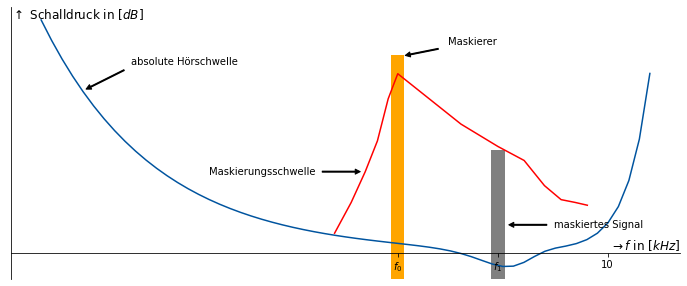

In [4]:
import sys
sys.path.insert(0,'ient_nb')

import matplotlib.pyplot as plt 
import matplotlib.pylab as pll

from IPython.display import set_matplotlib_formats
set_matplotlib_formats('pdf', 'png')
plt.rcParams['savefig.dpi'] = 300

data = pll.loadtxt('img/source/hoerschwelle.dat');

fig, ax = plt.subplots(figsize=(12,5))
ax.plot( data[:,0], data[:,1]);
rwth_plt.axis(ax);

data = pll.loadtxt('img/source/verdeckung2.dat');
ax.plot( data[:,0], data[:,1], color='red');
rwth_plt.axis(ax);

lim = ax.get_ylim();

ax.bar(1, height=80, width=0.15, bottom=lim[0], color="orange")
ax.bar(3, height=46, width=0.45, bottom=lim[0], color="grey")

plt.xscale('log',basex=2);
plt.xticks([1,3,10],["$f_0$","$f_1$",10]);
plt.yticks([]);
ax.set_xlabel(r'$\rightarrow f $ in $[kHz]$');
ax.set_ylabel(r'$\uparrow$ Schalldruck in $[dB]$');

ax.annotate('absolute Hörschwelle',
            xy=(0.031, 57.6), xycoords='data',
            xytext=(50, 25), textcoords='offset points',
            arrowprops=dict(facecolor='black', shrink=0.1, width=1, headlength=5, headwidth=5),
            horizontalalignment='left', verticalalignment='bottom')

ax.annotate('Maskierungsschwelle',
            xy=(0.7, 29), xycoords='data',
            xytext=(-50, 0), textcoords='offset points',
            arrowprops=dict(facecolor='black', shrink=0.1, width=1, headlength=5, headwidth=5),
            horizontalalignment='right', verticalalignment='center')

ax.annotate('Maskierer',
            xy=(1, 70), xycoords='data',
            xytext=(50, 10), textcoords='offset points',
            arrowprops=dict(facecolor='black', shrink=0.15, width=1, headlength=5, headwidth=5),
            horizontalalignment='left', verticalalignment='bottom')

ax.annotate('maskiertes Signal',
            xy=(3.2, 10), xycoords='data',
            xytext=(50, 0), textcoords='offset points',
            arrowprops=dict(facecolor='black', shrink=0.1, width=1, headlength=5, headwidth=5),
            horizontalalignment='left', verticalalignment='center')

plt.show()

>*Abbildung 7.4: Verdeckung eines Signals durch einen sog. Maskierer im Frequenzbereich* <cite data-cite="book:sprachsignalverarbeitung"></cite>

In Abb. 7.5 ist der Einfluss eines $70\text{dB }$ lauten Sinustons mit der Frequenz $1\text{kHz }$ auf die Hörschwelle skizziert. Als Verhältnis zwischen der maximalen Leistung eines sinusförmigen Testsignals und der Leistung des maskierenden Rauschsignals $P_N$ werden in der Literatur <cite data-cite="book:sprachsignalverarbeitung"></cite><cite data-cite="book:psychoacoustics"></cite> Werte von $3 - 6 \text{ dB}$ angegeben. Die Art der Verdeckung wird auch als *noise masking tone (NMT)*, *pure tone masked by noise* oder *pure tone masked by pure tone* bezeichnet <cite data-cite="book:psychoacoustics"></cite> . 

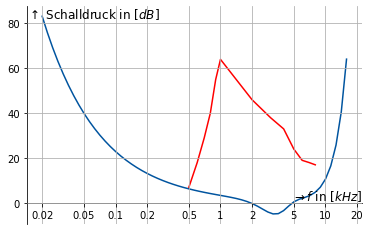

In [5]:
import sys
sys.path.insert(0,'ient_nb')

import matplotlib.pyplot as plt 
import matplotlib.pylab as pll

from IPython.display import set_matplotlib_formats
set_matplotlib_formats('pdf', 'png')
plt.rcParams['savefig.dpi'] = 300

data = pll.loadtxt('img/source/hoerschwelle.dat');

fig, ax = plt.subplots()
ax.plot( data[:,0], data[:,1]);
rwth_plt.axis(ax);

data = pll.loadtxt('img/source/verdeckung2.dat');
ax.plot( data[:,0], data[:,1],color='red');
rwth_plt.axis(ax);

plt.xscale('log',basex=2);
plt.xticks([0.02,0.05,0.1,0.2,0.5,1,2,5,10,20],[0.02,0.05,0.1,0.2,0.5,1,2,5,10,20]);
plt.grid()
ax.set_xlabel(r'$\rightarrow f $ in $[kHz]$');
ax.set_ylabel(r'$\uparrow$ Schalldruck in $[dB]$');

plt.show()

>*Abbildung 7.5: Veränderung der Hörschwelle durch einen Sinuston mit der Frequenz $f = 1\text{kHz}$ und einer Leistung $L = 70\text{dB}$* <cite data-cite="book:psychoacoustics"></cite>

Auf andere Verdeckungseffekte im Frequenzbereich, wie *tone masking noise*, bei dem der Einfluss eines Sinustons auf die Wahrnehmbarkeit von breitbandigem Rauschen untersucht
wird, soll im Rahmen dieses Praktikumsversuches nicht weiter eingegangen werden. 

#### Verdeckung im Zeitbereich

Bei einer starken Lautstärkeschwankung lässt sich ein weiterer Verdeckungseffekt beobachten: die *Verdeckung im Zeitbereich* <cite data-cite="book:psychoacoustics"></cite><cite data-cite="book:ohr"></cite>. Sowohl bei einer Lautstärkeänderung von laut nach leise als auch umgekehrt ist dieses Phänomen zu beobachten. 

Durch einen leistungsstarken Maskierer wird ein nachfolgendes, schwächeres Signal verdeckt. Erst nach etwa $200 \text{ms }$ erreicht die Empfindlichkeit des Ohrs wieder die Ruhempfindlichkeit (engl.: *Recovery Time*). Diese Art der Verdeckung wird als *Nachverdeckung* bezeichnet. Aber auch bei einem Lautstärkeübergang von leise nach laut ist im leisen Bereich eine Verdeckung zu beobachten (*Vorverdeckung*). 

Beide Arten der zeitlichen Verdeckung sind in Abbildung 7.6 skizziert. Im Rahmen des Praktikums soll aus Zeitgründen auf die Verdeckung im Zeitbereich ebenfalls nicht eingegangen werden.

![abb_7_6](img/abb_7_6.png)

>*Abbildung 7.6: Verdeckung im Zeitbereich*

## Das MP3-Kompressionsverfahren

Mit dem Standard *MPEG-1* wurde neben der Videocodierung auch der Versuch unternommen, Audiosignale (verlustbehaftet) zu komprimieren. In der endgültigen Version beinhaltet der MPEG-1 Standard drei verlustbehaftete Codierverfahren für Audiosignale, die als *Layer 1*, *Layer 2* und *Layer 3* bezeichnet werden. Sie nehmen mit größer werdendem Index in ihrer Qualität aber auch in ihrer Komplexität zu und sind zueinander abwärtskompatibel.

In diesem Praktikumsversuch wird der komplexeste aber auch berühmteste der drei Audio-Codecs vorgestellt (Codec ist ein Kunstwort aus **Co**der und **Dec**oder). Der *MPEG-1-Layer 3*, kurz MP3 genannt, ist vor allem durch die Musikübertragung über das Internet bekannt geworden. Sein Nachfolger AAC wird u.a. in iTunes verwendet. AAC basiert auf dem gleichen Grundprinzip, nutzt jedoch eine reine MDCT-Filterbank und zusätzliche Tricks, um eine noch höhere Kompressionsrate zu erzielen. 

![abb_7_7](img/abb_7_7.png)

>*Abbildung 7.7: Blockdiagramm eines ISO/MPEG/Audio Codierers, Layer III, Mono* <cite data-cite="article:ase:genericstandard"></cite>

In Abb. 7.7 ist die Strukutur des MP3-Kompressionsverfahrens dargestellt. Im Folgenden
werden die einzelnen Schritte detaillierter beschrieben.


### Hybride Filterbänke und MDCT

Das digitale Audiosignal wird zunächst in 32 Teilbänder zerlegt. Die Breiten der einzelnen Bandpassfilter sind an das menschliche Gehör angepasst. Jedes dieser Teilbänder wird anschließend mit Hilfe einer MDCT in 18 Teilbereiche unterteilt, wodurch bis zu 576 (=32·18) Kanäle entstehen (vgl. Abb. 7.7). Der AAC-Codec verwendet eine reine MDCT als Filterbank.

### Quantisierung

Anschließend werden die einzelnen Frequenzwerte quantisiert. Dabei wird ein nicht linearer Quantisierer eingesetzt.

\begin{equation}
    \displaystyle x_q = \text{sgn}(x)\cdot\left[\left(\frac{|x|}{d}\right)^{\frac{3}{4}}-0.0946\right] \tag{7.8}\label{Gl.7.8}
\end{equation}
mit

\begin{align*}
    |\dots|&: \text{Betragsfunktion} \\
    d&: \text{aktuelle Stufenbreite des Quantisierers}\\
    [\dots]&: \text{Gaußklammer}\\
    x_q&: \text{quantisierter Wert von $x$}\\
    \text{sgn}(x)&: \text{Vorzeichenfunktion (1 für positive, -1 für negative Werte)}\\
\end{align*}



Die Genauigkeit der Quantisierung (die aktuelle Stufenbreite des Quantisierers $d$) richtet sich nach der momentanen Hörschwelle des Ohres in den einzelnen Frequenzbändern.

### Das psychoakustische Modell

Bei der Quantisierung der einzelnen Frequenzbänder wird danach gestrebt, den Quantisierungsfehler (Differenzsignal zwischen Originalsignal und rekonstruiertem Signal) unterhalb der Hörbarkeitsschwelle zu halten. Die aktuelle Hörbarkeitsschwelle wird durch das *psychoakustische Modell* (vgl. Abb. 7.7) geschätzt. Das psychoakustische Modell berücksichtigt hierbei die Verdeckungseffekte im Zeit- und Frequenzbereich.

Im Laufe der Zeit wurde dieses Modell durch Hörtests immer wieder verfeinert und verbessert. Geschulten Testhörern (sog. *Golden Ears*) wurden dabei veränderte/verbesserte Versionen des psychoakustischen Modells vorgestellt und so versucht, die hörbaren Verfälschungen zu minimieren oder gar ganz zu eliminieren. So wurde beispielsweise festgestellt, dass harmonische und unharmonische Signale unterschiedliche Verdeckungseigenschaften aufweisen<cite data-cite="article:ase:genericstandard"></cite>.

Die Implementierung des psychoakustischen Modells ist der Hauptunterschied zwischen den unterschiedlichen MP3-Codierern und maßgeblich für die Qualität des Codierers verantwortlich. Da bei MP3 nur der Decodierer standardisiert ist, nicht jedoch der Codierer, wird den Entwicklern genug Spielraum gegeben, das akustische Modell zu optimieren.

### Huffman Codierung

Die Frequenzwerte werden nach ihrer Quantisierung Huffman-codiert. Dabei wird häufig auftretenden Werten ein kurzes Codewort (mit wenigen Bits) zugewiesen, während Werte, die weniger häufig vorkommen, ein längeres Codewort bekommen. Der genaue Algorithmus der Huffman-Codierung ist u. a. in <cite data-cite="book:signaluebertragung">(Lüke und Ohm, 2014)</cite>,<cite data-cite="script:mmk1">(Ohm, 2015)</cite> beschrieben.

### MP3 Decodierer

![abb_7_8](img/abb_7_8.png)

>*Abbildung 7.8: Blockdiagramm eines MP3 Decoders*

Die Decodierung eines MP3-Datenstroms ist im Vergleich zu der Codierung deutlich einfacher. Hauptaufgabe bei der Decodierung ist die Invertierung der einzelnen Codierschritte (vgl. Abb. 7.8). Eine Kenntnis des psychoakustischen Modells ist nicht notwendig. Im Gegensatz zum Codierer ist der Decodierer im Standard fest definiert. Verbesserungen des MP3-Verfahrens finden somit ausschließlich auf der Codiererseite statt.

Für an den technischen Details des MP3-Codecs, wie der *Bit-Reservoir Technik*, der *Struktur des Bit-Streams* oder der Codierung von *Stereo Signalen* interessierte Studenten sei auf <cite data-cite="article:ase:genericstandard">(Brandenburg und Stoll, 1995)</cite> verwiesen. 